In [1]:
!pip install tabpfn -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 753.2/753.2 kB 14.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 77.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 279.3/279.3 kB 17.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 5.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.39.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
google-adk 1.29.0 requires google-cloud-bigquery-storage>=2.0.0, which is not installed.
ydata-profiling 4.18.4 requires numba<0.63,>=0.60, but you have numba 0.65.1 which is incompatible.
ydata-profiling 4.18.4 requires numpy<2.4,>=1.22, but you have numpy 2.4.6 which is incompatible.
google-colab 1.0.0 requires jupyter-server==2.14.0, but you have jupyter-server 2.12.5 which is incompatible.
google-colab 

In [2]:
import os
import time
import numpy as np
import pandas as pd
import torch
from tabpfn import TabPFNClassifier
from sklearn.metrics import (
    f1_score, roc_auc_score, average_precision_score,
    precision_score, recall_score
)

os.environ["TABPFN_TOKEN"] = "tabpfn_sk_CybtFp0-L9rlGEEnpx0QwhmXaz0a7mO22XgkyiPQMaI"

SEED   = 42
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
np.random.seed(SEED)
torch.manual_seed(SEED)

print("Device:", DEVICE)
print("GPU   :", torch.cuda.get_device_name(0) if DEVICE == 'cuda' else "-")

Device: cuda
GPU   : Tesla T4


In [3]:
BASE     = '/kaggle/input/datasets/jasonkmrkn/fp-ml-sba-artifacts'
BASE_CLU = '/kaggle/input/datasets/jasonkmrkn/fp-ml-clustering-artifacs'

X_train = pd.read_parquet(f'{BASE}/X_train_encoded.parquet')
X_val   = pd.read_parquet(f'{BASE}/X_val_encoded.parquet')
X_test  = pd.read_parquet(f'{BASE}/X_test_encoded.parquet')

y_train = pd.read_parquet(f'{BASE}/y_train.parquet')['Default']
y_val   = pd.read_parquet(f'{BASE}/y_val.parquet')['Default']
y_test  = pd.read_parquet(f'{BASE}/y_test.parquet')['Default']

print(f"X_train : {X_train.shape} | Default rate: {y_train.mean():.4f}")
print(f"X_val   : {X_val.shape}  | Default rate: {y_val.mean():.4f}")
print(f"X_test  : {X_test.shape}  | Default rate: {y_test.mean():.4f}")

X_train : (174993, 46) | Default rate: 0.1756
X_val   : (37507, 46)  | Default rate: 0.1756
X_test  : (37500, 46)  | Default rate: 0.1756


In [4]:
clust_train = pd.read_parquet(f'{BASE_CLU}/X_train.parquet')
clust_val   = pd.read_parquet(f'{BASE_CLU}/X_val.parquet')
clust_test  = pd.read_parquet(f'{BASE_CLU}/X_test.parquet')

X_train_enh = pd.concat([X_train.reset_index(drop=True), clust_train.reset_index(drop=True)], axis=1)
X_val_enh   = pd.concat([X_val.reset_index(drop=True),   clust_val.reset_index(drop=True)],   axis=1)
X_test_enh  = pd.concat([X_test.reset_index(drop=True),  clust_test.reset_index(drop=True)],  axis=1)

print(f"Baseline : {X_train.shape[1]} fitur")
print(f"Enhanced : {X_train_enh.shape[1]} fitur")

Baseline : 46 fitur
Enhanced : 66 fitur


In [5]:
results = []

def evaluate(y_true, y_proba, label, split='val'):
    y_pred = (y_proba >= 0.5).astype(int)
    row = {
        'Skenario' : label,
        'Split'    : split,
        'F1'       : round(f1_score(y_true, y_pred), 4),
        'ROC-AUC'  : round(roc_auc_score(y_true, y_proba), 4),
        'PR-AUC'   : round(average_precision_score(y_true, y_proba), 4),
        'Precision': round(precision_score(y_true, y_pred, zero_division=0), 4),
        'Recall'   : round(recall_score(y_true, y_pred), 4),
    }
    results.append(row)
    print(f"{label} [{split}]  F1={row['F1']}  ROC-AUC={row['ROC-AUC']}  PR-AUC={row['PR-AUC']}")
    return row

def run_tabpfn(n_estimators, X_fit, y_fit, X_eval):
    model = TabPFNClassifier(
        n_estimators=n_estimators,
        device=DEVICE,
        random_state=SEED,
        ignore_pretraining_limits=True,
    )
    t0 = time.perf_counter()
    model.fit(X_fit, y_fit)
    fit_t = time.perf_counter() - t0

    t0 = time.perf_counter()
    proba = model.predict_proba(X_eval)[:, 1]
    pred_t = time.perf_counter() - t0

    print(f"  fit={fit_t:.1f}s  predict={pred_t:.1f}s")
    return model, proba

# Skenario 1 - Baseline vs With Cluster Features

In [6]:
print("1a - Baseline...")
model_1a, proba_1a_val = run_tabpfn(4, X_train, y_train, X_val)
row_1a_val = evaluate(y_val, proba_1a_val, '1a Baseline', split='val')

1a - Baseline...


tabpfn-v3-classifier-v3_default.ckpt:   0%|          | 0.00/213M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/33.0 [00:00<?, ?B/s]

  fit=8.6s  predict=714.6s
1a Baseline [val]  F1=0.8635  ROC-AUC=0.983  PR-AUC=0.9336


In [7]:
print("1b - With Cluster...")
model_1b, proba_1b_val = run_tabpfn(4, X_train_enh, y_train, X_val_enh)
row_1b_val = evaluate(y_val, proba_1b_val, '1b Enhanced', split='val')

1b - With Cluster...
  fit=7.5s  predict=756.9s
1b Enhanced [val]  F1=0.8672  ROC-AUC=0.9835  PR-AUC=0.935


In [8]:
ablation = pd.DataFrame([
    {'Metric': 'F1',        '1a Baseline': row_1a_val['F1'],        '1b Enhanced': row_1b_val['F1']},
    {'Metric': 'ROC-AUC',   '1a Baseline': row_1a_val['ROC-AUC'],   '1b Enhanced': row_1b_val['ROC-AUC']},
    {'Metric': 'PR-AUC',    '1a Baseline': row_1a_val['PR-AUC'],    '1b Enhanced': row_1b_val['PR-AUC']},
    {'Metric': 'Precision', '1a Baseline': row_1a_val['Precision'], '1b Enhanced': row_1b_val['Precision']},
    {'Metric': 'Recall',    '1a Baseline': row_1a_val['Recall'],    '1b Enhanced': row_1b_val['Recall']},
])
ablation['Delta'] = (ablation['1b Enhanced'] - ablation['1a Baseline']).round(4)
display(ablation)

,Metric,1a Baseline,1b Enhanced,Delta
0,F1,0.8635,0.8672,0.0037
1,ROC-AUC,0.9830,0.9835,0.0005
2,PR-AUC,0.9336,0.9350,0.0014
3,Precision,0.9025,0.9025,0.0000
4,Recall,0.8278,0.8346,0.0068


# Grafik Perbandingan Baseline vs Fitur Clustering

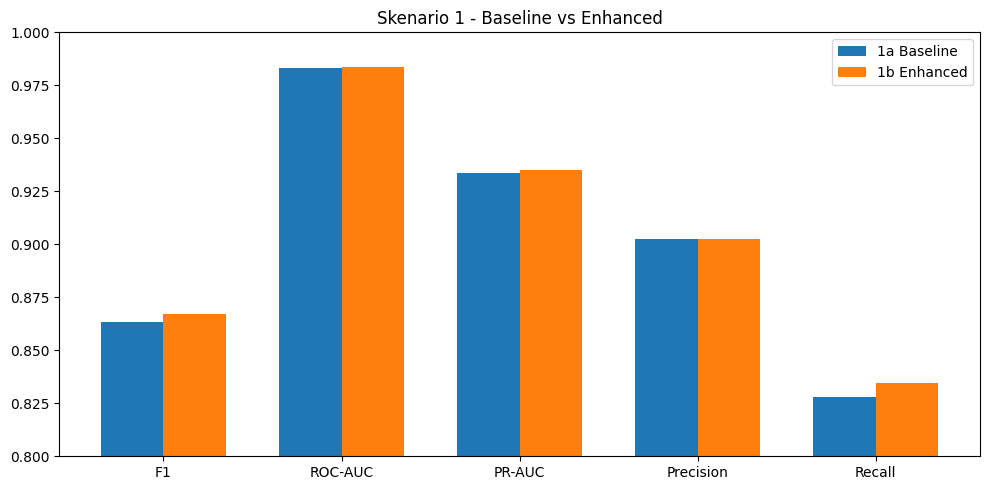

In [9]:
import matplotlib.pyplot as plt

metrics = ['F1', 'ROC-AUC', 'PR-AUC', 'Precision', 'Recall']
vals_1a = [row_1a_val['F1'], row_1a_val['ROC-AUC'], row_1a_val['PR-AUC'], row_1a_val['Precision'], row_1a_val['Recall']]
vals_1b = [row_1b_val['F1'], row_1b_val['ROC-AUC'], row_1b_val['PR-AUC'], row_1b_val['Precision'], row_1b_val['Recall']]

x = range(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar([i - width/2 for i in x], vals_1a, width, label='1a Baseline')
ax.bar([i + width/2 for i in x], vals_1b, width, label='1b Enhanced')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0.8, 1.0)
ax.set_title('Skenario 1 - Baseline vs Enhanced')
ax.legend()
plt.tight_layout()
plt.savefig('skenario1_comparison.png', dpi=120)
plt.show()

In [10]:
# Evaluasi best model Skenario 1 di test set
if row_1b_val['F1'] >= row_1a_val['F1']:
    best_model_s1      = model_1b
    best_label_s1      = '1b Enhanced'
    X_test_s1          = X_test_enh
else:
    best_model_s1      = model_1a
    best_label_s1      = '1a Baseline'
    X_test_s1          = X_test

print(f"Best Skenario 1: {best_label_s1}")

proba_s1_test = best_model_s1.predict_proba(X_test_s1)[:, 1]
row_s1_test   = evaluate(y_test, proba_s1_test, best_label_s1, split='test')

Best Skenario 1: 1b Enhanced
1b Enhanced [test]  F1=0.8716  ROC-AUC=0.9832  PR-AUC=0.9335


# Skenario 2 - Hyperparameter Tuning n_estimators

In [11]:
# Gunakan data dari best model Skenario 1
if best_label_s1 == '1b Enhanced':
    X_fit_s2, X_val_s2, X_test_s2 = X_train_enh, X_val_enh, X_test_enh
else:
    X_fit_s2, X_val_s2, X_test_s2 = X_train, X_val, X_test

print(f"Data yang digunakan: {best_label_s1}")

Data yang digunakan: 1b Enhanced


In [12]:
N_EST_GRID = [2, 4, 8, 16]
s2_models  = {}
s2_probas  = {}

for n_est in N_EST_GRID:
    print(f"\nn_estimators={n_est}...")
    model, proba = run_tabpfn(n_est, X_fit_s2, y_train, X_val_s2)
    s2_models[n_est] = model
    s2_probas[n_est] = proba
    evaluate(y_val, proba, f'2 n_est={n_est}', split='val')
    torch.cuda.empty_cache()


n_estimators=2...
  fit=6.6s  predict=378.0s
2 n_est=2 [val]  F1=0.8673  ROC-AUC=0.9834  PR-AUC=0.9346

n_estimators=4...
  fit=7.4s  predict=763.1s
2 n_est=4 [val]  F1=0.8678  ROC-AUC=0.9835  PR-AUC=0.935

n_estimators=8...
  fit=9.3s  predict=1519.7s
2 n_est=8 [val]  F1=0.8676  ROC-AUC=0.9835  PR-AUC=0.9348

n_estimators=16...
  fit=12.9s  predict=3038.4s
2 n_est=16 [val]  F1=0.8674  ROC-AUC=0.9835  PR-AUC=0.9352


In [13]:
df_s2_val = pd.DataFrame([r for r in results if r['Skenario'].startswith('2')])
display(df_s2_val)

best_n_est = int(df_s2_val.loc[df_s2_val['F1'].idxmax(), 'Skenario'].split('=')[1])
print(f"Best n_estimators: {best_n_est}")

,Skenario,Split,F1,ROC-AUC,PR-AUC,Precision,Recall
0,2 n_est=2,val,0.8673,0.9834,0.9346,0.9006,0.8363
1,2 n_est=4,val,0.8678,0.9835,0.9350,0.9033,0.8350
2,2 n_est=8,val,0.8676,0.9835,0.9348,0.9031,0.8348
3,2 n_est=16,val,0.8674,0.9835,0.9352,0.9024,0.8351


Best n_estimators: 4


# Grafik F1 vs n_estimators

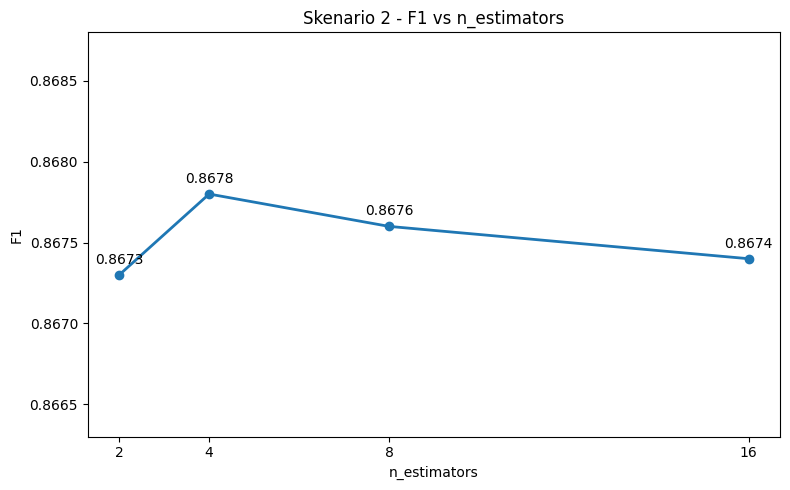

In [14]:
n_est_list = [2, 4, 8, 16]
f1_list = [r['F1'] for r in results if r['Skenario'].startswith('2') and r['Split'] == 'val']

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(n_est_list, f1_list, marker='o', linewidth=2)
ax.set_xticks(n_est_list)
ax.set_xlabel('n_estimators')
ax.set_ylabel('F1')
ax.set_title('Skenario 2 - F1 vs n_estimators')
ax.set_ylim(min(f1_list) - 0.001, max(f1_list) + 0.001)
for i, v in zip(n_est_list, f1_list):
    ax.annotate(f'{v:.4f}', (i, v), textcoords='offset points', xytext=(0, 8), ha='center')
plt.tight_layout()
plt.savefig('skenario2_nestimators.png', dpi=120)
plt.show()

In [15]:
# Evaluasi best model Skenario 2 di test set
print(f"Evaluasi n_est={best_n_est} di test set...")
proba_s2_test = s2_models[best_n_est].predict_proba(X_test_s2)[:, 1]
row_s2_test   = evaluate(y_test, proba_s2_test, f'2 n_est={best_n_est}', split='test')

Evaluasi n_est=4 di test set...
2 n_est=4 [test]  F1=0.8706  ROC-AUC=0.9832  PR-AUC=0.9331


# Grafik Val vs Test Best Model per Skenario

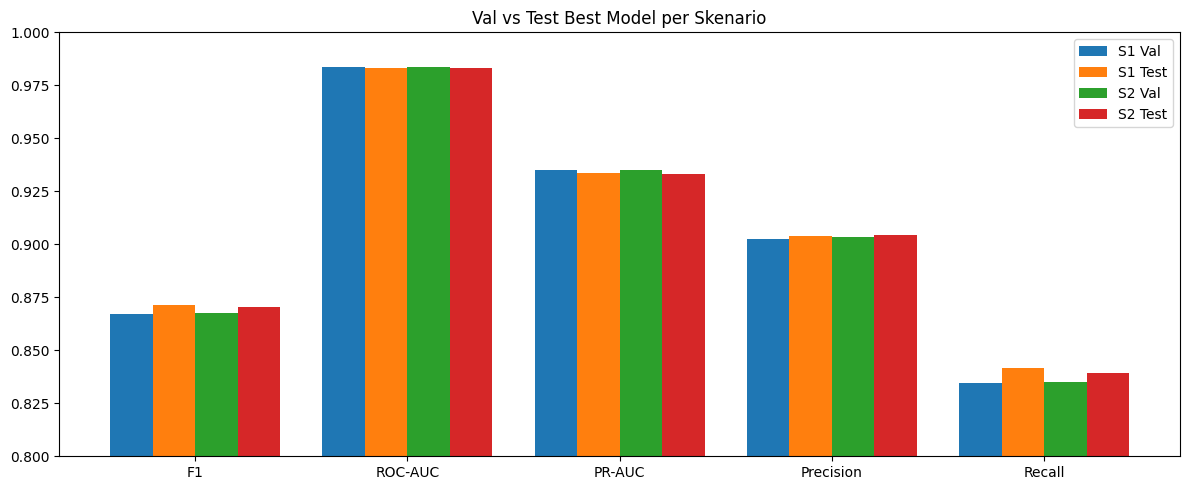

In [16]:
import matplotlib.pyplot as plt

metrics = ['F1', 'ROC-AUC', 'PR-AUC', 'Precision', 'Recall']

s1_val  = [row_1b_val[m] for m in metrics]
s1_test = [row_s1_test[m] for m in metrics]

s2_val_row  = next(r for r in results if r['Skenario'] == f'2 n_est={best_n_est}' and r['Split'] == 'val')
s2_test_row = next(r for r in results if r['Skenario'] == f'2 n_est={best_n_est}' and r['Split'] == 'test')

s2_val_vals  = [s2_val_row[m] for m in metrics]
s2_test_vals = [s2_test_row[m] for m in metrics]

x = range(len(metrics))
width = 0.2

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar([i - width*1.5 for i in x], s1_val,       width, label='S1 Val')
ax.bar([i - width*0.5 for i in x], s1_test,      width, label='S1 Test')
ax.bar([i + width*0.5 for i in x], s2_val_vals,  width, label='S2 Val')
ax.bar([i + width*1.5 for i in x], s2_test_vals, width, label='S2 Test')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0.8, 1.0)
ax.set_title('Val vs Test Best Model per Skenario')
ax.legend()
plt.tight_layout()
plt.savefig('val_vs_test.png', dpi=120)
plt.show()

# Result

In [17]:
df_all = pd.DataFrame(results)
display(df_all)
df_all.to_csv('tabpfn_results.csv', index=False)
print("Saved: tabpfn_results.csv")

,Skenario,Split,F1,ROC-AUC,PR-AUC,Precision,Recall
0,1a Baseline,val,0.8635,0.9830,0.9336,0.9025,0.8278
1,1b Enhanced,val,0.8672,0.9835,0.9350,0.9025,0.8346
2,1b Enhanced,test,0.8716,0.9832,0.9335,0.9038,0.8416
3,2 n_est=2,val,0.8673,0.9834,0.9346,0.9006,0.8363
4,2 n_est=4,val,0.8678,0.9835,0.9350,0.9033,0.8350
5,2 n_est=8,val,0.8676,0.9835,0.9348,0.9031,0.8348
6,2 n_est=16,val,0.8674,0.9835,0.9352,0.9024,0.8351
7,2 n_est=4,test,0.8706,0.9832,0.9331,0.9042,0.8395


Saved: tabpfn_results.csv
